In [1]:
import pandas as pd

In [10]:
df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")

/tmp/ipykernel_15047/3662128544.py:1: DtypeWarning: Columns (49,50,51,52,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")


In [30]:
df["d"] = 1000*(1/df["Parallax"])

In [58]:
df = df.loc[df["Parallax"]>0]

In [59]:
O_stars = df.loc[df["label"]<1].sample(100)
later_stars = df.loc[df["label"]>2].sample(100)

In [60]:
data = pd.concat([later_stars[["d","Jmag",'BPmag-RPmag','Hmag-Ksmag',"B2"]],O_stars[["d","Jmag",'BPmag-RPmag','Hmag-Ksmag',"B2"]]])

In [61]:
import seaborn as sns

<Axes: xlabel='d', ylabel='Count'>

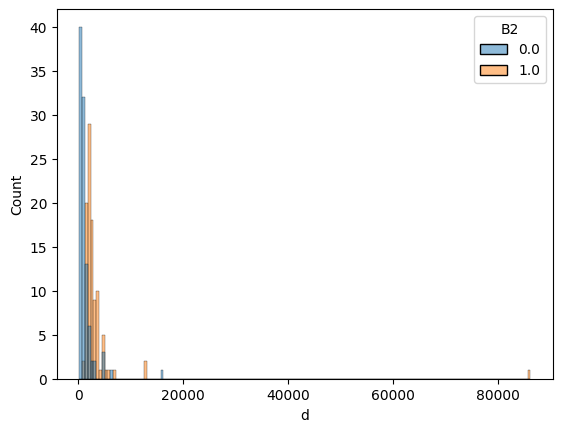

In [62]:
sns.histplot(data=data,x="d",hue="B2")

In [69]:
data.loc[data["d"]<=1500].groupby("B2").count()

,d,Jmag,BPmag-RPmag,Hmag-Ksmag
B2,,,,
0.0,82,82,82,82
1.0,8,8,8,8


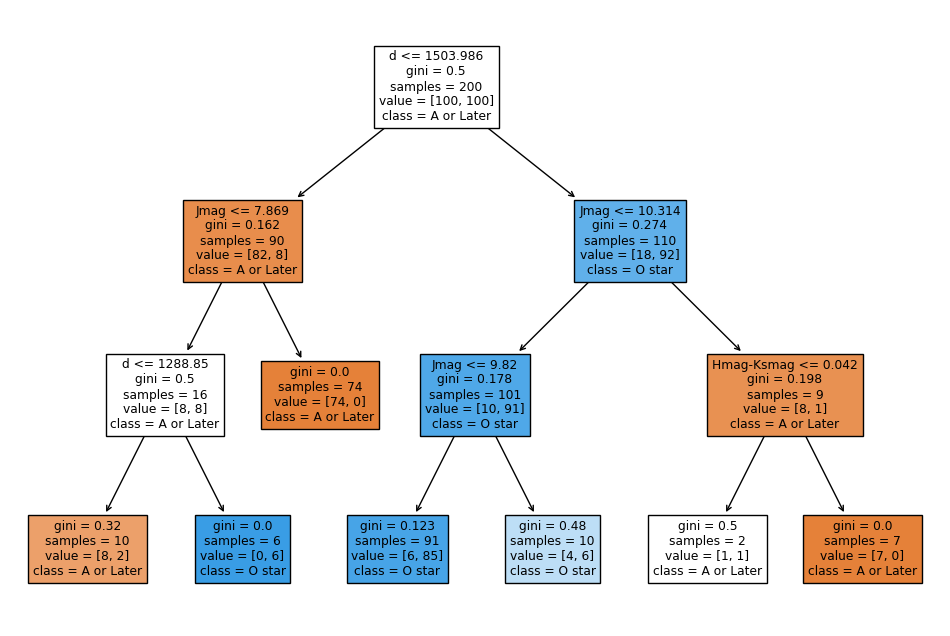

In [65]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Cargar dataset
iris = load_iris()
X, y = data[["d","Jmag",'BPmag-RPmag','Hmag-Ksmag']].values, data["B2"].values

# Entrenar el modelo
clf = DecisionTreeClassifier(random_state=0,max_depth=3)
clf.fit(X, y)

# Graficar el árbol de decisión
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=["d","Jmag",'BPmag-RPmag','Hmag-Ksmag'], class_names=["A or Later","O star"])
plt.savefig("tree.pdf",dpi=300)

In [ ]:
#periodo 
#amplitud
#2 mas, importantes revisar paper de paula
